# 05 — Segment Analysis

## Context
The primary analysis gave us an overall answer. Segment analysis asks: **is the effect uniform, or is it driven by a specific type of client?**

This matters for two reasons:
1. **Product decision**: If the new UX only helps younger clients, a targeted rollout might make more sense than a full deployment
2. **Risk management**: If a segment shows negative lift, a full rollout could harm those users

### ⚠️ A note on segment analysis
These breakdowns by age, balance, and gender were exploratory — we looked at them after seeing the overall result, not before. That means they're useful for spotting patterns and generating hypotheses, but not for drawing firm conclusions. If a particular segment looks interesting, the right next step is a dedicated experiment targeting that group specifically.

To reduce the chance of false positives across multiple tests, 
we apply Bonferroni correction — raising the significance threshold 
proportionally to the number of comparisons made.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
COLORS = {'Test': '#2563EB', 'Control': '#94A3B8'}
ALPHA = 0.05

df = pd.read_csv('../output/df_analysis_client_level.csv')

## 1. Helper Function

In [2]:
def segment_test(df_seg, segment_label):
    """Run two-proportion z-test for a given segment subset."""
    test = df_seg[df_seg['Variation'] == 'Test']
    ctrl = df_seg[df_seg['Variation'] == 'Control']

    if len(test) < 30 or len(ctrl) < 30:
        return None  # Too small for reliable inference

    x_test, n_test = test['completed'].sum(), len(test)
    x_ctrl, n_ctrl = ctrl['completed'].sum(), len(ctrl)

    rate_test = x_test / n_test
    rate_ctrl = x_ctrl / n_ctrl
    rel_lift = (rate_test - rate_ctrl) / rate_ctrl if rate_ctrl > 0 else np.nan

    z, p = proportions_ztest([x_test, x_ctrl], [n_test, n_ctrl])

    return {
        'Segment': segment_label,
        'Test Rate': rate_test,
        'Control Rate': rate_ctrl,
        'Abs Lift': rate_test - rate_ctrl,
        'Rel Lift': rel_lift,
        'p-value': p,
        'n_test': n_test,
        'n_ctrl': n_ctrl
    }

## 2. Age Group Analysis

In [3]:
df['age_group'] = pd.cut(
    df['clnt_age'],
    bins=[0, 30, 45, 60, 120],
    labels=['Under 30', '30–44', '45–59', '60+']
)

age_results = []
for grp in df['age_group'].cat.categories:
    sub = df[df['age_group'] == grp]
    result = segment_test(sub, str(grp))
    if result:
        age_results.append(result)

df_age = pd.DataFrame(age_results)

# Bonferroni correction
n_tests = len(df_age)
df_age['p-value (adj)'] = (df_age['p-value'] * n_tests).clip(upper=1)
df_age['Significant?'] = df_age['p-value (adj)'].apply(lambda p: '✅' if p < ALPHA else '—')

display(df_age[['Segment', 'Test Rate', 'Control Rate', 'Abs Lift', 'Rel Lift', 'p-value', 'p-value (adj)', 'Significant?']].round(4))

,Segment,Test Rate,Control Rate,Abs Lift,Rel Lift,p-value,p-value (adj),Significant?
0,Under 30,0.7167,0.6547,0.0620,0.0948,0.0000,0.0000,✅
1,30–44,0.6961,0.6644,0.0317,0.0477,0.0001,0.0003,✅
2,45–59,0.6785,0.6598,0.0187,0.0284,0.0132,0.0526,—
3,60+,0.6632,0.6114,0.0518,0.0847,0.0000,0.0000,✅


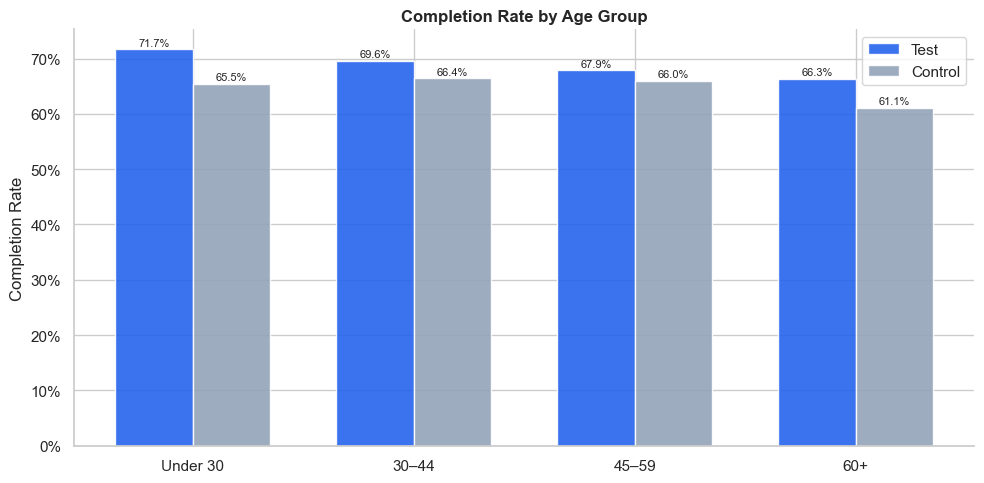

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(df_age))
width = 0.35

bars_t = ax.bar(x - width/2, df_age['Test Rate'], width, label='Test', color=COLORS['Test'], alpha=0.9)
bars_c = ax.bar(x + width/2, df_age['Control Rate'], width, label='Control', color=COLORS['Control'], alpha=0.9)

for bar in bars_t:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.1%}', ha='center', va='bottom', fontsize=8)
for bar in bars_c:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.1%}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(df_age['Segment'])
ax.set_title('Completion Rate by Age Group', fontsize=12, fontweight='bold')
ax.set_ylabel('Completion Rate')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig('../output/segment_age.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Account Balance Tier Analysis

In [6]:
df['balance_tier'] = pd.qcut(
    df['bal'].fillna(0),
    q=3,
    labels=['Low Balance', 'Mid Balance', 'High Balance']
)

bal_results = []
for grp in ['Low Balance', 'Mid Balance', 'High Balance']:
    sub = df[df['balance_tier'] == grp]
    result = segment_test(sub, grp)
    if result:
        bal_results.append(result)

df_bal = pd.DataFrame(bal_results)
df_bal['p-value (adj)'] = (df_bal['p-value'] * len(df_bal)).clip(upper=1)
df_bal['Significant?'] = df_bal['p-value (adj)'].apply(lambda p: '✅' if p < ALPHA else '—')

display(df_bal[['Segment', 'Test Rate', 'Control Rate', 'Abs Lift', 'Rel Lift', 'p-value', 'p-value (adj)', 'Significant?']].round(4))

,Segment,Test Rate,Control Rate,Abs Lift,Rel Lift,p-value,p-value (adj),Significant?
0,Low Balance,0.6888,0.6517,0.0371,0.0569,0.0,0.0,✅
1,Mid Balance,0.6770,0.6387,0.0382,0.0598,0.0,0.0,✅
2,High Balance,0.6948,0.6560,0.0388,0.0591,0.0,0.0,✅


## 4. Gender Analysis

In [7]:
gen_results = []
for g in df['gendr'].dropna().unique():
    sub = df[df['gendr'] == g]
    result = segment_test(sub, f'Gender: {g}')
    if result:
        gen_results.append(result)

df_gen = pd.DataFrame(gen_results)
df_gen['p-value (adj)'] = (df_gen['p-value'] * len(df_gen)).clip(upper=1)
df_gen['Significant?'] = df_gen['p-value (adj)'].apply(lambda p: '✅' if p < ALPHA else '—')

display(df_gen[['Segment', 'Test Rate', 'Control Rate', 'Abs Lift', 'Rel Lift', 'p-value', 'Significant?']].round(4))

,Segment,Test Rate,Control Rate,Abs Lift,Rel Lift,p-value,Significant?
0,Gender: M,0.7034,0.6591,0.0443,0.0671,0.0,✅
1,Gender: F,0.6612,0.6256,0.0356,0.0569,0.0,✅


## 5. Relative Lift Summary Chart (All Segments)

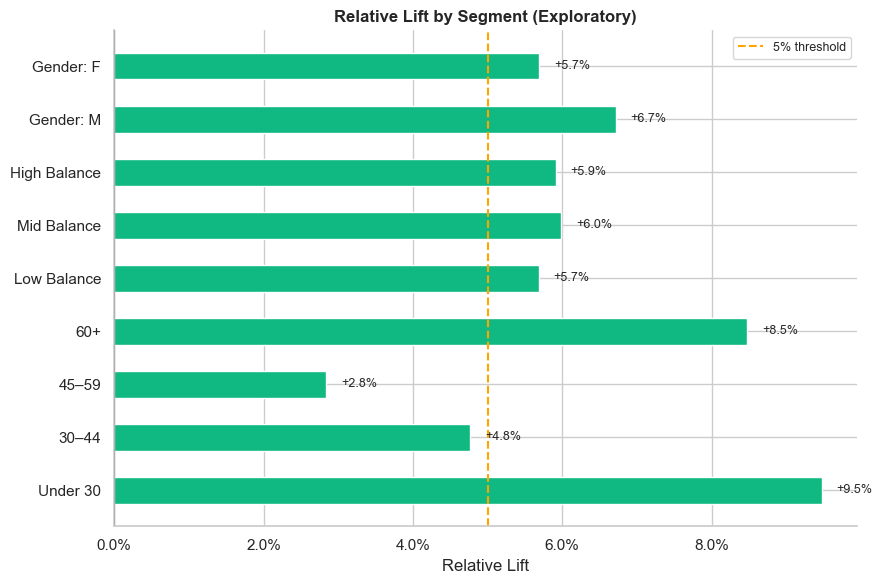

In [8]:
all_segments = pd.concat([df_age, df_bal, df_gen], ignore_index=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#10B981' if x > 0 else '#EF4444' for x in all_segments['Rel Lift']]
bars = ax.barh(all_segments['Segment'], all_segments['Rel Lift'], color=colors, height=0.5, edgecolor='white')

ax.axvline(0, color='black', linewidth=0.8)
ax.axvline(0.05, color='orange', linewidth=1.5, linestyle='--', label='5% threshold')

for bar, val in zip(bars, all_segments['Rel Lift']):
    ax.text(
        val + (0.002 if val >= 0 else -0.002),
        bar.get_y() + bar.get_height()/2,
        f'{val:+.1%}', va='center',
        ha='left' if val >= 0 else 'right',
        fontsize=9
    )

ax.set_xlabel('Relative Lift')
ax.set_title('Relative Lift by Segment (Exploratory)', fontsize=12, fontweight='bold')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.legend(fontsize=9)
sns.despine()
plt.tight_layout()
plt.savefig('../output/segment_lift_summary.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary

Segment analysis reveals whether the UX improvement is universal or concentrated. Segments showing outsized positive lift may be candidates for targeted UX personalization in future iterations. Segments showing no lift (or negative lift) should be examined for friction points introduced by the new design.

**Remember:** these are exploratory findings. Act on patterns, not on individual segment p-values.